In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy
eps_double = np.finfo(float).eps


In [ ]:
%run Streaming_DMD_functions.ipynb #or full directory if not in the same folder

In [ ]:
## SIMULATION OF CHUA SYSTEM - code adjusted from https://chuacircuits.com/matlab/ 
## simulation continues for specific t_max, dt, initial state in Chua_DMD below.

def chua_system(t, state, alpha, beta, m0, m1):  
    x, y, z = state
    
    h = m1 * x + 0.5 * (m0 - m1) * (np.abs(x + 1) - np.abs(x - 1))
    
    xdot = alpha * (y - x - h)
    ydot = x - y + z
    zdot = -beta * y
    
    return [xdot, ydot, zdot]

alpha = 15.6
beta = 28
m0 = -1.143
m1 = -0.714


In [30]:
def Chua_DMD(t_max, dt, initial_state, q, ylim=(1e-14, 1e1)):
    t_span = (0, t_max)
    t_eval = np.linspace(t_span[0], t_span[1], int(t_max/dt))   

    sol = solve_ivp(
        chua_system, 
        t_span, 
        initial_state, 
        args=(alpha, beta, m0, m1), 
        t_eval=t_eval,
        method='RK45' 
    )

    sol = sol.y
    data = np.vstack((sol, sol**2))

    del(sol)

    (m,n) = data.shape

    #####################################################################################################
    ord_od = 2

    a_sm = []
    a_tq = []
    a_chol = []
    cond_num = []

    #######################################################################################################
    #####  

    R, Q = scipy.linalg.rq(data[:,: q], mode="economic") #returns R and Q^T
    Gyq = data[:, 1:q+1]@(Q.T)
    del(Q)

    Gx = data[:, :q]@(data[:, :q].T)
    try:
        Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")
    except np.linalg.LinAlgError:
        Px = np.linalg.pinv(Gx)
    A_sm = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T
    del(Gx)

    Qc, Rc = scipy.linalg.qr(data[:, :q].T, mode="economic")
    Achol = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

    for k in range(q, n-1):

        Gyq, R = updateYQT(Gyq, R, data[:, k].reshape(-1,1), data[:, k+1].reshape(-1,1), 0,0,tri='U')
        A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T
        a_tq.append(np.linalg.norm(scipy.linalg.solve_triangular(R.T, Gyq.T, lower=True).T-A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od)) #isto kao pinv

        z = Px@(data[:, k].reshape(-1,1))
        gamma = 1/(1+data[:,k].reshape(1,-1)@z)
        A_sm= A_sm + (gamma*(data[:, k+1].reshape(-1,1)-A_sm@(data[:, k].reshape(-1,1))))@z.T
        Px = Px-gamma*(z@z.T) 
        a_sm.append(np.linalg.norm(A_sm-A_batch, ord=ord_od)/np.linalg.norm(A_batch,ord=ord_od))

        first = scipy.linalg.solve_triangular(Rc.T, data[:, k].reshape(-1,1), lower=True)
        px = scipy.linalg.solve_triangular(Rc, first, lower=False) 
        gamma = 1/(1+first.T@first)
        gamma = gamma[0,0]
        Achol = Achol + (gamma*(data[:, k+1].reshape(-1,1)-Achol@(data[:, k].reshape(-1,1))))@px.T
        Rc = R_update(Rc, data[:, k])
        a_chol.append(np.linalg.norm(Achol - A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od))
        
        svds = np.linalg.svdvals(data[:, :k])
        cond_num.append(max(svds)/min(svds))

  

    plt.figure(figsize=(6,4))
    plt.plot(a_sm, label="$SM$", marker='', ls="--", lw=3)
    plt.plot(a_chol, label="Chol", ls="--", marker='', lw=3)
    plt.plot(a_tq, label="TQ", ls="--", marker='')
    plt.plot((m*eps_double)*np.array(cond_num), label="$m\epsilon \kappa_2(X)$", marker="", lw=3.5, color="red")
    plt.grid()
    plt.title("Error for $A$")
    plt.legend()
    plt.figtext(0.5, -0.03, "$x_0$={}, $t$ = {}, $\Delta t$ = {}, $n_0 = {}$ ".format(initial_state, t_span, t_span[1]/len(t_eval), q), ha='center', fontsize=10, weight=500)


    plt.yscale('log')
    plt.ylim(ylim)

### FIG. 8a)

- $x_0 = [-0.7, 0.1, 0.1], \Delta t = 10^{-3}$

C:\Users\elawi\AppData\Local\Temp\ipykernel_29992\3901575435.py:37: LinAlgWarning: Ill-conditioned matrix (rcond=3.95451e-17): result may not be accurate.
  Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")


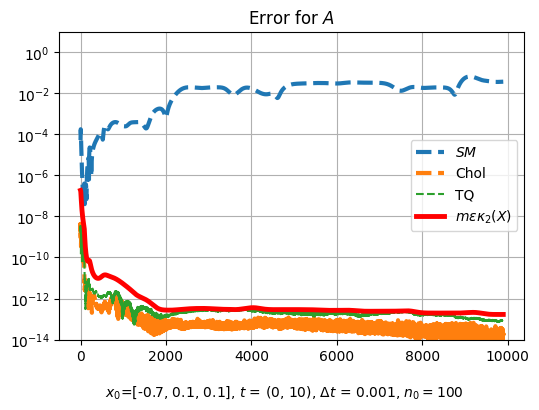

In [25]:
Chua_DMD(10, 1e-3, [-0.7, 0.1, 0.1], 100)

### FIG 8b)

- $x_0 = [-0.7, 0.1, 0.1], \Delta t = 10^{-4}$

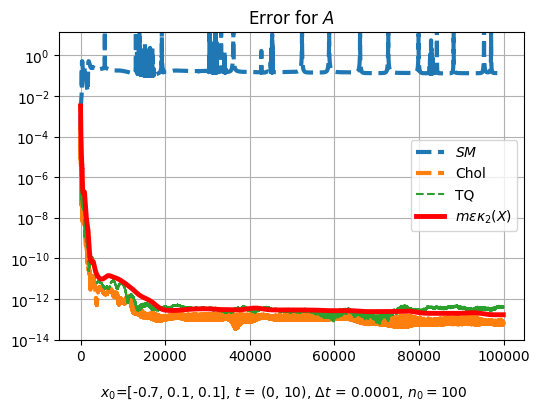

In [31]:
Chua_DMD(10, 1e-4, [-0.7, 0.1, 0.1], 100, (1e-14, 15))

### FIG 8c)

- $x_0 = [-10.7, 0, 0], \Delta t = 10^{-3}, t_{max}=30$

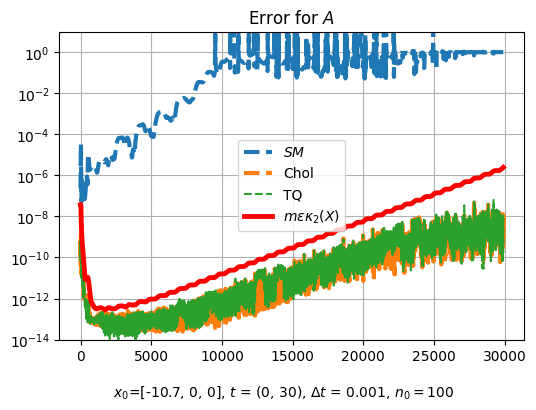

In [23]:
Chua_DMD(30, 1e-3, [-10.7,0,0], 100)

### FIG. 9a)

- $x_0 = [-10.7, 0, 0], $\Delta t = 10^{-3}, t_{max} = 30, n_0 = 250$

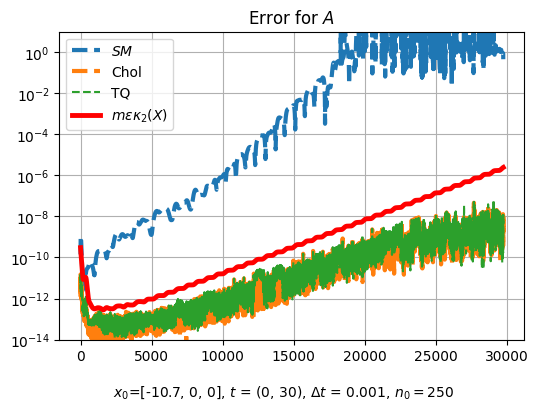

In [26]:
Chua_DMD(30, 1e-3, [-10.7,0,0], 250)

### FIG. 9b)  

- $x_0 = [-10.7, 0, 0], \Delta t = 10^{-3}, t_{max} = 70, n_0 =100$

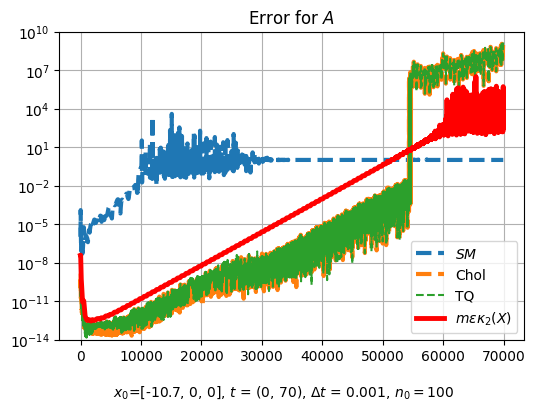

In [28]:
Chua_DMD(70, 1e-3, [-10.7, 0,0], 100, (1e-14, 1e10))

### FIG. 9c)

- $x_0 = [10^{-15}, 0, 0], \Delta t = 10^{-3}, t_{max} = 10, n_0 = 50$

C:\Users\elawi\AppData\Local\Temp\ipykernel_29992\3901575435.py:37: LinAlgWarning: Ill-conditioned matrix (rcond=5.48951e-44): result may not be accurate.
  Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")


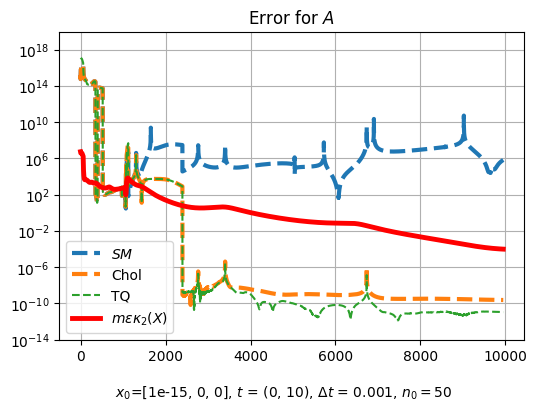

In [27]:
Chua_DMD(10, 1e-3, [1e-15,0,0], 50, (1e-14,1e20))